# FINANCE 384 --- Lecture 3

## Volatility and Business News

Companion to **Application 2** of the lecture. The *Nowcasting from 180 News Topics* slide
shows Bybee, Kelly, Manela, and Xiu (2024) regressing macroeconomic growth on 180
news-attention series. We put the CBOE VIX on the left-hand side instead:

$$\log \mathrm{VIX}_t = \beta_0 + \sum_{j=1}^{180}\beta_j\,\theta_{j,t} + \varepsilon_t ,$$

where $\theta_{j,t}$ is the share of business-news attention devoted to topic $j$ in month
$t$. There are 180 predictors and 330 months --- fewer than two observations per
coefficient.

The notebook runs two exercises:

- **Nowcast** (Section 2) --- what does the news say about *this* month's volatility?
  Following Bybee et al., the five selected topics are compared against OLS on all 180.
- **Forecast** (Section 3) --- which topics predict *next* month's volatility? The five are
  chosen on the training block and scored on months the model has never seen.

**After this notebook you should be able to:**

1. use the lasso as a selection device and defend the results;
2. explain why a sparse model can beat a far better-fitting one out of sample;
3. standardise using training-sample moments only.


## 1. Setup and data

The VIX is CBOE's 30-day implied volatility index on the S&P 500, published daily since
January 1990. `VIX_History.csv` holds the data.

We use the **monthly average** of daily closes, not the month-end close, because the news
shares are themselves an average over the month.

`Monthly_Topic_Attention_Theta.csv` holds the topic model of Bybee et al. (2024): a latent
Dirichlet allocation fitted to the full text of the *Wall Street Journal*, 1984--2017,
giving 180 interpretable topics. Each entry is the share of that month's news attention
devoted to one topic, so the 180 shares sum to one.


In [75]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error

pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

SEED = 384
N_TOPICS_WANTED = 5                           # how many topics the lasso may keep
TRAIN_END = pd.Period("2005-12", freq="M")    # Section 3: last month used to estimate
VALID_END = pd.Period("2011-12", freq="M")    # Section 3: last month used to check the penalty

BLUE = "#003865"
GREEN = "#64A70B"
GOLD = "#F2A900"
RED = "#DA291C"


In [76]:
vix_daily = pd.read_csv("VIX_History.csv", parse_dates=["DATE"], date_format="%m/%d/%Y")
vix_daily = vix_daily.set_index("DATE").sort_index()

# Daily closes -> monthly average, dropping any partial month at the end of the file
by_month = vix_daily["CLOSE"].groupby(vix_daily.index.to_period("M"))
monthly = by_month.agg(["mean", "count"])
vix_monthly = monthly.loc[monthly["count"] >= 15, "mean"].rename("vix")
vix_monthly.index.name = "month"

topics = pd.read_csv("Monthly_Topic_Attention_Theta.csv", parse_dates=["date"])
topics["month"] = topics["date"].dt.to_period("M")
topics = topics.drop(columns="date").set_index("month").sort_index()
TOPIC_NAMES = topics.columns.tolist()

data = topics.join(vix_monthly, how="inner").dropna()
data["log_vix"] = np.log(data["vix"])

n = len(data)
k = len(TOPIC_NAMES)

print(f"VIX    : {len(vix_daily):,} trading days, {vix_monthly.index.min()} to "
      f"{vix_monthly.index.max()}")
print(f"Topics : {len(topics)} months, {k} series, {topics.index.min()} to "
      f"{topics.index.max()}")
print(f"Merged : {n} months ({data.index.min()} to {data.index.max()})")
print(f"n / k  : {n / k:.2f} observations per coefficient")


VIX    : 9,243 trading days, 1990-01 to 2026-07
Topics : 402 months, 180 series, 1984-01 to 2017-06
Merged : 330 months (1990-01 to 2017-06)
n / k  : 1.83 observations per coefficient


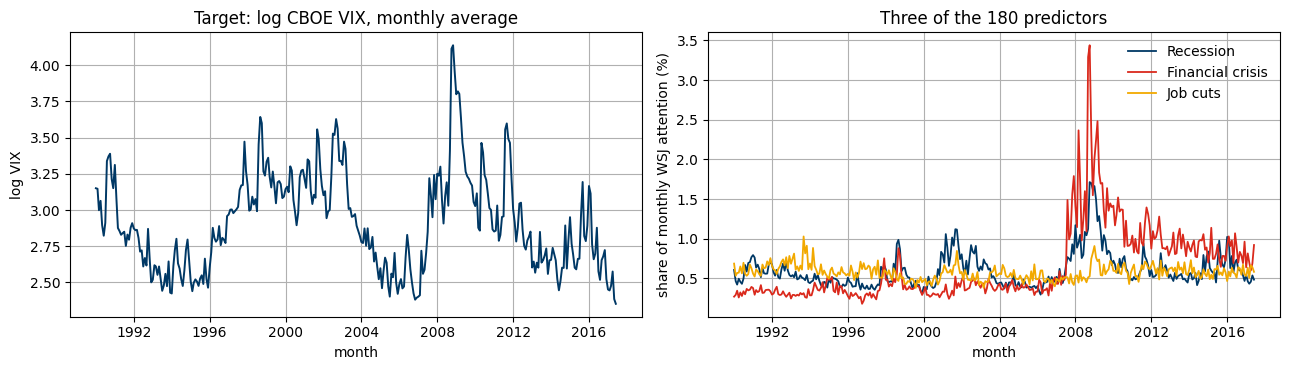

In [77]:
months = data.index.to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))

axes[0].plot(months, data["log_vix"], color=BLUE, lw=1.4)
axes[0].set_ylabel("log VIX")
axes[0].set_xlabel("month")
axes[0].set_title("Target: log CBOE VIX, monthly average")

axes[1].plot(months, 100 * data["Recession"], color=BLUE, lw=1.3, label="Recession")
axes[1].plot(months, 100 * data["Financial crisis"], color=RED, lw=1.3, label="Financial crisis")
axes[1].plot(months, 100 * data["Job cuts"], color=GOLD, lw=1.3, label="Job cuts")
axes[1].set_ylabel("share of monthly WSJ attention (%)")
axes[1].set_xlabel("month")
axes[1].set_title("Three of the 180 predictors")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()


## 2. Nowcasting: five topics that explain the VIX

Bybee et al. report which topics carry the signal, not just how well the model fits. We do
the same.

This section deliberately uses the **whole sample**, because the question is
descriptive --- *what does business news say about volatility?* --- not predictive.

The comparison is OLS on all 180 topics. Both models see identical data. They differ only
in whether coefficient size is penalized.


In [78]:
X_full = (data[TOPIC_NAMES] - data[TOPIC_NAMES].mean()) / data[TOPIC_NAMES].std(ddof=0)
y_full = data["log_vix"]

# Walk the penalty down until the fifth topic enters
penalty_path = np.logspace(0, -4, 600)
for penalty in penalty_path:
    lasso_nowcast = Lasso(alpha=penalty, max_iter=200_000, random_state=SEED)
    lasso_nowcast.fit(X_full, y_full)
    if (lasso_nowcast.coef_ != 0).sum() >= N_TOPICS_WANTED:
        break

ols_nowcast = LinearRegression().fit(X_full, y_full)

lasso_coefficients = pd.Series(lasso_nowcast.coef_, index=TOPIC_NAMES)
ols_coefficients = pd.Series(ols_nowcast.coef_, index=TOPIC_NAMES)
selected = lasso_coefficients[lasso_coefficients != 0].sort_values()

print(f"Lasso penalty at which {len(selected)} topics have entered: {penalty:.4f}\n")

pd.DataFrame([
    {
        "model": f"lasso, {len(selected)} topics",
        "R-squared": lasso_nowcast.score(X_full, y_full),
        "coefficients used": len(selected),
        "largest |coefficient|": lasso_coefficients.abs().max(),
    },
    {
        "model": f"OLS, all {k} topics",
        "R-squared": ols_nowcast.score(X_full, y_full),
        "coefficients used": k,
        "largest |coefficient|": ols_coefficients.abs().max(),
    },
]).set_index("model").round(4)


Lasso penalty at which 5 topics have entered: 0.0854



,R-squared,coefficients used,largest |coefficient|
model,,,
"lasso, 5 topics",0.5183,5,0.0897
"OLS, all 180 topics",0.9422,180,0.1405


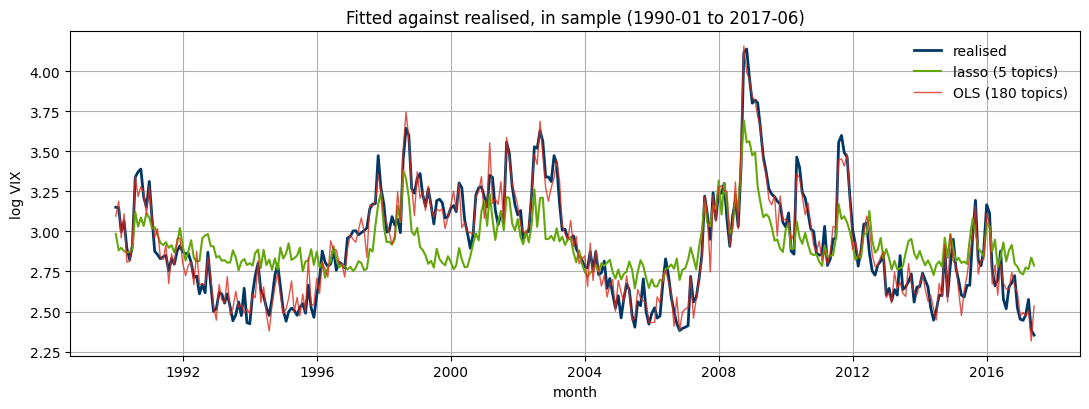

In [79]:
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(months, y_full, color=BLUE, lw=2, label="realised")
ax.plot(months, lasso_nowcast.predict(X_full), color=GREEN, lw=1.5,
        label=f"lasso ({len(selected)} topics)")
ax.plot(months, ols_nowcast.predict(X_full), color=RED, lw=1.0, alpha=0.8,
        label=f"OLS ({k} topics)")
ax.set_ylabel("log VIX")
ax.set_xlabel("month")
ax.set_title(f"Fitted against realised, in sample ({data.index.min()} to {data.index.max()})")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


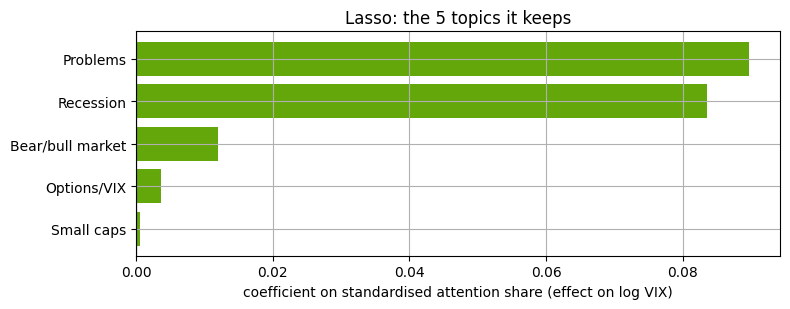

In [80]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(range(len(selected)), selected.to_numpy(), color=GREEN)
ax.set_yticks(range(len(selected)))
ax.set_yticklabels(selected.index)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("coefficient on standardised attention share (effect on log VIX)")
ax.set_title(f"Lasso: the {len(selected)} topics it keeps")
plt.tight_layout()
plt.show()


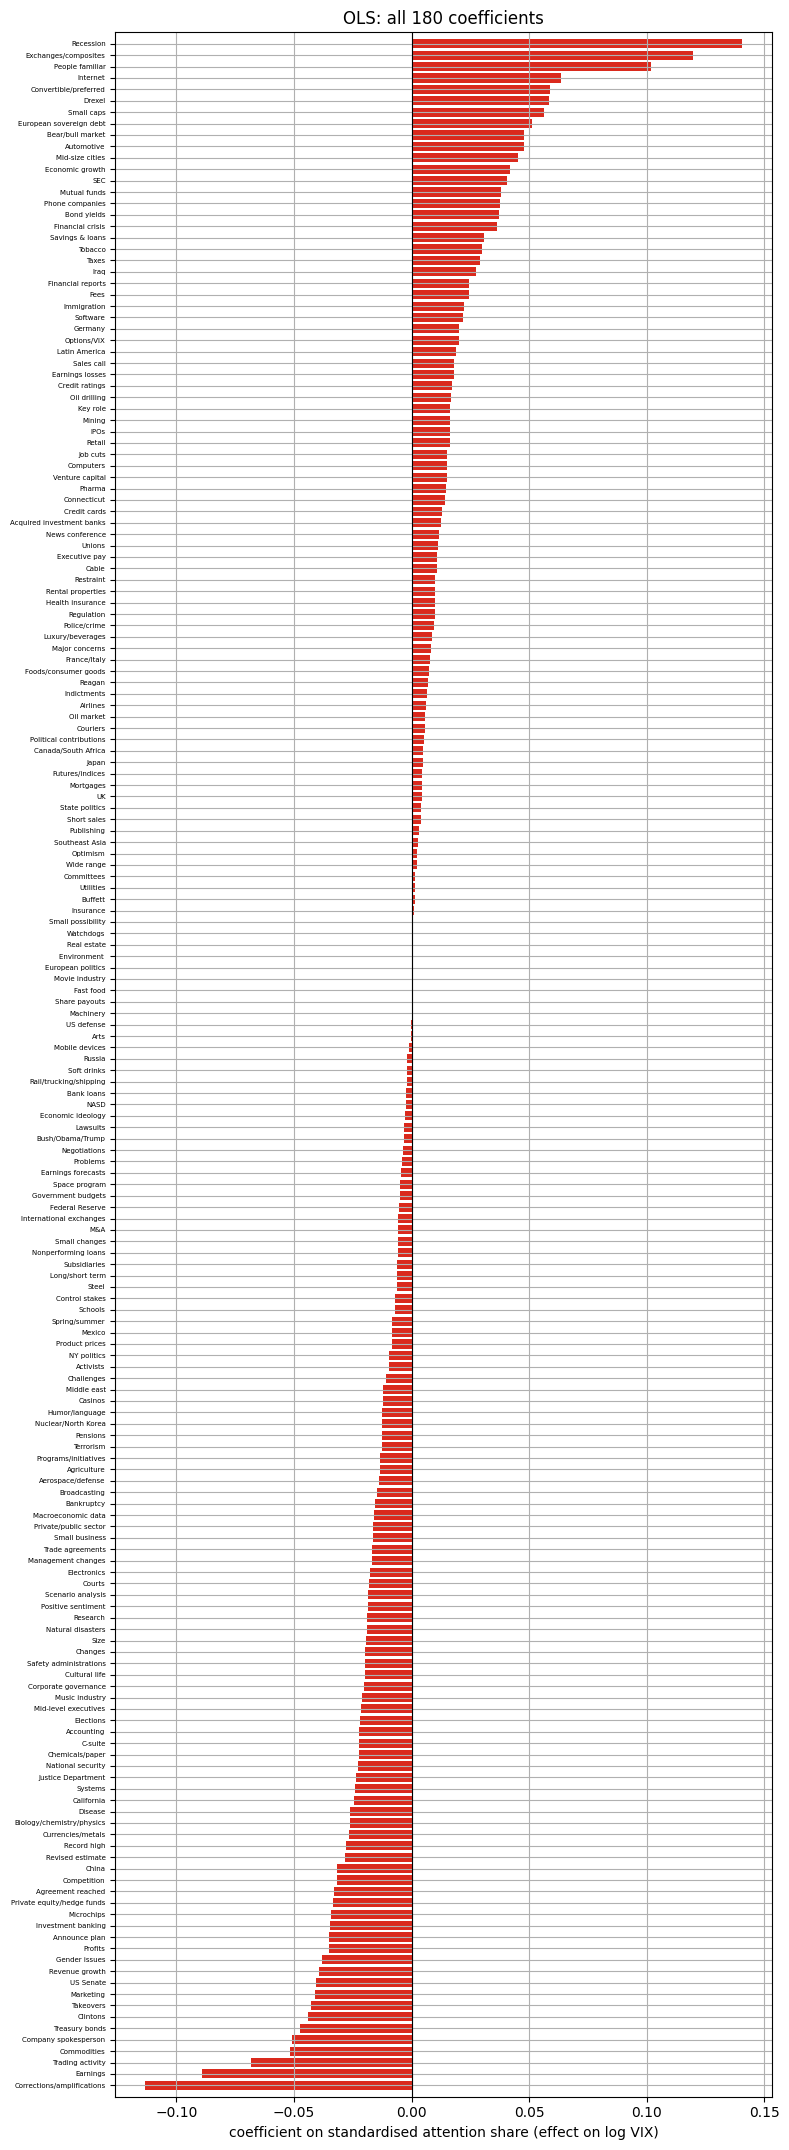

In [81]:
ols_sorted = ols_coefficients.sort_values()

fig, ax = plt.subplots(figsize=(8, 0.12 * k))
ax.barh(range(k), ols_sorted.to_numpy(), color=RED)
ax.set_yticks(range(k))
ax.set_yticklabels(ols_sorted.index, fontsize=5)
ax.axvline(0, color="black", lw=0.8)
ax.set_ylim(-1, k)
ax.set_xlabel("coefficient on standardised attention share (effect on log VIX)")
ax.set_title(f"OLS: all {k} coefficients")
plt.tight_layout()
plt.show()


## 3. Forecasting: which topics predict next month?

Section 2 asked what the news says about volatility *now*. But does it also forecast volatility?

The sample is cut three ways.

**Stage 1 --- select (Section 3.1).** Estimate on the **train** block and use the
**validation** block to select the hyperparameters. Standardisation uses training-block
moments only.

**Stage 2 --- estimate (Section 3.2).** Models whose settings do not come from validation
error are then estimated on **train + validation**, with standardisation recomputed on that
combined block.

The **test** block is touched once, in Section 3.3, and never before.


In [82]:
lagged = pd.concat([data[TOPIC_NAMES].shift(1), data[["log_vix"]]], axis=1).dropna()

train = lagged.loc[:TRAIN_END]
valid = lagged.loc[(lagged.index > TRAIN_END) & (lagged.index <= VALID_END)]
test = lagged.loc[lagged.index > VALID_END]


def standardise(block, fitted_on):
    """Standardise `block` using the mean and standard deviation of `fitted_on`."""
    return (block[TOPIC_NAMES] - fitted_on[TOPIC_NAMES].mean()) / fitted_on[TOPIC_NAMES].std(ddof=0)


X_train = standardise(train, fitted_on=train)
X_valid = standardise(valid, fitted_on=train)
y_train = train["log_vix"]
y_valid = valid["log_vix"]
y_test = test["log_vix"]

for name, block in [("train", train), ("validation", valid), ("test", test)]:
    print(f"{name:<11}: {block.index.min()} to {block.index.max()}  {len(block):>3} months  "
          f"peak VIX {np.exp(block['log_vix'].max()):.0f}")


train      : 1990-02 to 2005-12  191 months  peak VIX 38
validation : 2006-01 to 2011-12   72 months  peak VIX 63
test       : 2012-01 to 2017-06   66 months  peak VIX 24


### 3.1 Selecting the topics

The figure below is the check. It traces validation error against the number of topics the
lasso keeps, and marks two choices: the five-topic model, and the penalty that simply
minimises validation MSE. The second keeps far more topics for a small gain, and Section
3.3 shows what that costs on months neither model has seen.


five topics      : penalty 0.1215,   5 topics, validation MSE 0.1685
lowest validation: penalty 0.0046,  80 topics, validation MSE 0.1482


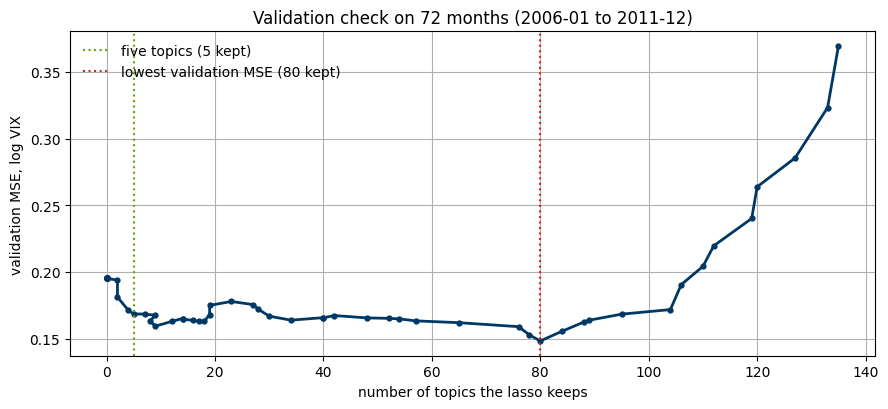

In [83]:
penalty_grid = np.logspace(0, -3, 60)

validation_mse = []
topics_kept = []
for penalty in penalty_grid:
    model = Lasso(alpha=penalty, max_iter=200_000, random_state=SEED)
    model.fit(X_train, y_train)
    validation_mse.append(mean_squared_error(y_valid, model.predict(X_valid)))
    topics_kept.append((model.coef_ != 0).sum())

validation_mse = np.array(validation_mse)
topics_kept = np.array(topics_kept)

five_topic_index = np.where(topics_kept >= N_TOPICS_WANTED)[0].min()
lowest_mse_index = validation_mse.argmin()
lowest_mse_penalty = penalty_grid[lowest_mse_index]

print(f"five topics      : penalty {penalty_grid[five_topic_index]:.4f}, "
      f"{topics_kept[five_topic_index]:>3} topics, validation MSE "
      f"{validation_mse[five_topic_index]:.4f}")
print(f"lowest validation: penalty {lowest_mse_penalty:.4f}, "
      f"{topics_kept[lowest_mse_index]:>3} topics, validation MSE "
      f"{validation_mse[lowest_mse_index]:.4f}")

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(topics_kept, validation_mse, color=BLUE, lw=2, marker="o", ms=3.5)
ax.axvline(topics_kept[five_topic_index], color=GREEN, lw=1.5, ls=":",
           label=f"five topics ({topics_kept[five_topic_index]} kept)")
ax.axvline(topics_kept[lowest_mse_index], color=RED, lw=1.5, ls=":",
           label=f"lowest validation MSE ({topics_kept[lowest_mse_index]} kept)")
ax.set_xlabel("number of topics the lasso keeps")
ax.set_ylabel("validation MSE, log VIX")
ax.set_title(f"Validation check on {len(valid)} months "
             f"({valid.index.min()} to {valid.index.max()})")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### 3.2 Estimating the final models

The **five-topic lasso** and **OLS** are estimated on train + validation. Neither takes a
setting from validation error --- the lasso follows the five-topic rule, OLS has nothing to
tune --- so holding those six years back would discard data sitting entirely before the test
period, in a problem with 180 coefficients and 191 training months.

The **lowest-validation-MSE lasso** stays on the train block alone. Its penalty was chosen
by minimising validation error, so estimating it on the validation months would fit it to
the data that selected it.

One detail: the five-topic rule is re-applied rather than the penalty reused, because
`scikit-learn` scales the lasso objective by $1/(2n)$ --- the same `alpha` shrinks by a
different amount on a larger sample.

Nothing here touches the test block.


In [84]:
fit_block = lagged.loc[:VALID_END]                  # train + validation
X_fit = standardise(fit_block, fitted_on=fit_block)
y_fit = fit_block["log_vix"]

# Each model carries the standardisation of the block it was estimated on
X_test_fit = standardise(test, fitted_on=fit_block)
X_test_train = standardise(test, fitted_on=train)

# Five-topic rule, re-applied on train + validation
for penalty in np.logspace(0, -4, 600):
    forecast_model = Lasso(alpha=penalty, max_iter=200_000, random_state=SEED)
    forecast_model.fit(X_fit, y_fit)
    if (forecast_model.coef_ != 0).sum() >= N_TOPICS_WANTED:
        break

# Benchmark: unpenalized OLS on all 180 lagged topics, same estimation sample
ols_forecast_model = LinearRegression().fit(X_fit, y_fit)

# Selected by validation error, so estimated on the train block only
lowest_mse_model = Lasso(alpha=lowest_mse_penalty, max_iter=200_000, random_state=SEED)
lowest_mse_model.fit(X_train, y_train)

forecast_coefficients = pd.Series(forecast_model.coef_, index=TOPIC_NAMES)
forecast_topics = forecast_coefficients[forecast_coefficients != 0].sort_values()

print(f"lasso, five topics     : {len(fit_block)} months (train+validation), "
      f"penalty {penalty:.4f}, {len(forecast_topics)} topics")
print(f"OLS                    : {len(fit_block)} months (train+validation), "
      f"{k} topics, training R-squared {ols_forecast_model.score(X_fit, y_fit):.4f}")
print(f"lasso, lowest-MSE rule : {len(train)} months (train only), "
      f"penalty {lowest_mse_penalty:.4f}, {(lowest_mse_model.coef_ != 0).sum()} topics")


lasso, five topics     : 263 months (train+validation), penalty 0.1012, 5 topics
OLS                    : 263 months (train+validation), 180 topics, training R-squared 0.9466
lasso, lowest-MSE rule : 191 months (train only), penalty 0.0046, 80 topics


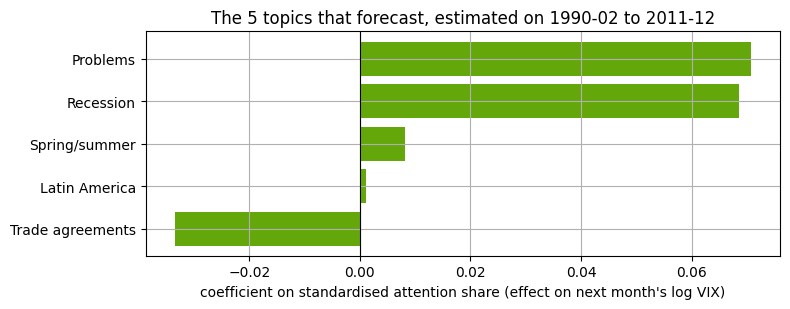

In [85]:
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.barh(range(len(forecast_topics)), forecast_topics.to_numpy(), color=GREEN)
ax.set_yticks(range(len(forecast_topics)))
ax.set_yticklabels(forecast_topics.index)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("coefficient on standardised attention share (effect on next month's log VIX)")
ax.set_title(f"The {len(forecast_topics)} topics that forecast, estimated on "
             f"{fit_block.index.min()} to {fit_block.index.max()}")
plt.tight_layout()
plt.show()


### 3.3 Out-of-sample test

Three forecasts, none of which has seen the test block: the two lasso models and the same
OLS benchmark as Section 2.

$R^2$ is measured against one common yardstick --- the mean log VIX over every month before
the test period --- so the three rows are comparable even though they were estimated on
different samples. It is $0$ for a model that does no better than that flat forecast, and
**negative** for one that does worse.


In [86]:
def evaluate(predicted, label):
    """MSE, MAE, and out-of-sample R-squared against the pre-test mean log VIX."""
    actual = y_test.to_numpy()
    predicted = np.asarray(predicted, dtype=float)
    flat_forecast = np.full(len(actual), y_fit.mean())

    model_mse = mean_squared_error(actual, predicted)
    flat_mse = mean_squared_error(actual, flat_forecast)

    return {
        "model": label,
        "MSE": model_mse,
        "MAE": mean_absolute_error(actual, predicted),
        "R2 vs pre-test mean": 1 - model_mse / flat_mse,
    }


results = pd.DataFrame([
    evaluate(forecast_model.predict(X_test_fit), f"lasso, {len(forecast_topics)} topics"),
    evaluate(lowest_mse_model.predict(X_test_train),
             f"lasso, lowest validation MSE ({(lowest_mse_model.coef_ != 0).sum()} topics)"),
    evaluate(ols_forecast_model.predict(X_test_fit), f"OLS, all {k} topics"),
]).set_index("model")

print(f"Test months: {test.index.min()} to {test.index.max()} ({len(test)} months)\n")
results.round(4)


Test months: 2012-01 to 2017-06 (66 months)



,MSE,MAE,R2 vs pre-test mean
model,,,
"lasso, 5 topics",0.0791,0.2501,0.1480
"lasso, lowest validation MSE (80 topics)",0.0952,0.2753,-0.0253
"OLS, all 180 topics",0.4073,0.5569,-3.3883


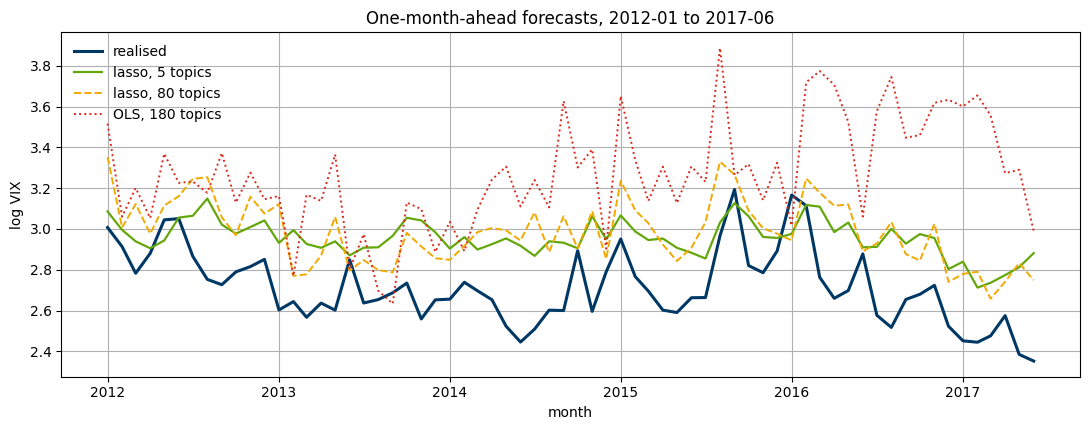

In [87]:
test_months = test.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.plot(test_months, y_test, color=BLUE, lw=2.2, label="realised")
ax.plot(test_months, forecast_model.predict(X_test_fit), color=GREEN, lw=1.6,
        label=f"lasso, {len(forecast_topics)} topics")
ax.plot(test_months, lowest_mse_model.predict(X_test_train), color=GOLD, lw=1.4, ls="--",
        label=f"lasso, {(lowest_mse_model.coef_ != 0).sum()} topics")
ax.plot(test_months, ols_forecast_model.predict(X_test_fit), color=RED, lw=1.4, ls=":",
        label=f"OLS, {k} topics")
ax.set_ylabel("log VIX")
ax.set_xlabel("month")
ax.set_title(f"One-month-ahead forecasts, {test.index.min()} to {test.index.max()}")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


## Extension questions

1. **Is the five-topic list stable?** Rerun Section 2 on 1990--2003 and on 2004--2017
   separately. How many of the five appear in both?
2. **How many topics should the model keep?** Change `N_TOPICS_WANTED` to 3, 10, and 25 and
   re-run both sections.
3. **Does the news add anything to persistence?** Volatility is highly persistent, so add
   last month's log VIX to the forecasting predictor set and re-run Section 3.
